## Executive Summary & Business Recommendations

### Executive Summary
1. **Objective:** Built and evaluated machine learning classification models to automate credit risk assessment and predict loan approval status (`Loan_Status`) based on applicant financial and demographic features.
2. **Top Model Performance:** The **Random Forest Classifier** achieved the highest overall accuracy (**82.50%**) on the unseen test dataset, matching the performance of a properly scaled **Logistic Regression** model (**82.08%**).
3. **Primary Predictive Drivers:**
   * **Credit History:** Having a positive credit repayment record is the single most decisive factor driving approval outcomes.
   * **Financial Ratios:** `ApplicantIncome` and `LoanAmount` carry high relative feature importance, indicating that debt-to-income balance heavily influences decision boundaries.
   * **Low Demographic Bias:** Features such as `Gender` and `Self_Employed` demonstrated minimal linear correlation with approval outcomes.

---

### Business Recommendations
* **Automate Low-Risk Approvals:** Integrate the Random Forest model into the front-end intake system to grant instant, automated approvals for high-confidence applicants (e.g., strong credit history with balanced income-to-loan ratios), reducing manual underwriting delays.
* **Refine Missing Data Imputation:** Move from global mean/mode imputation to **predictive imputation (e.g., KNN Imputation)** for missing financial values before production deployment to avoid distorting real-world applicant risk profiles.
* **Flag False-Positive Edge Cases for Human Review:** Configure an automated threshold where marginal applicants (e.g., high loan request relative to income despite a good credit score) are routed to human loan officers for secondary risk evaluation.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("LoanApprovalPrediction.csv")

In [3]:
data.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
obj = (data.dtypes == 'object')
print("Categorical variables:", len(list(obj[obj].index)))

Categorical variables: 7


In [5]:
# Dropping Loan_ID column
data.drop(['Loan_ID'],axis=1,inplace=True)

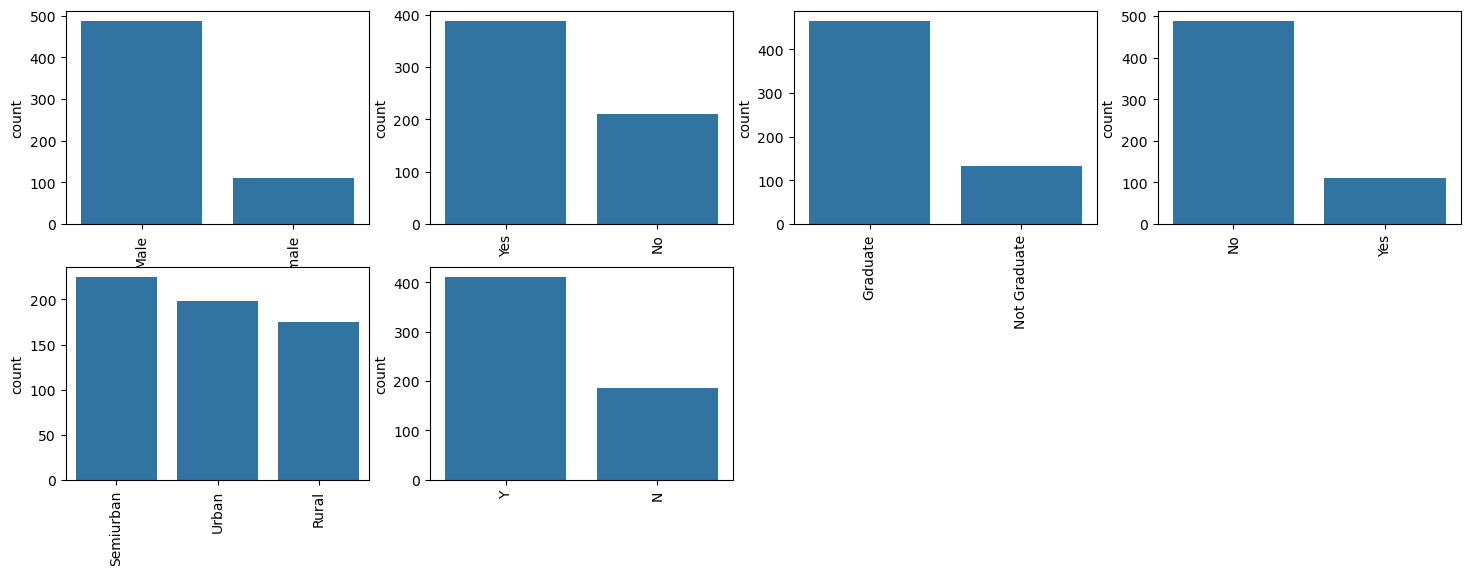

In [6]:
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)
plt.figure(figsize=(18,36))
index = 1

for col in object_cols:
  y = data[col].value_counts()
  plt.subplot(11,4,index)
  plt.xticks(rotation=90)
  sns.barplot(x=list(y.index), y=y)
  index +=1

In [7]:
print("Loan_ID" in data.columns)

False


In [8]:
data.head(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
# --- DOMAIN FEATURE ENGINEERING ---
# 1. Total Household Solvency
data['Total_Income'] = data['ApplicantIncome'] + data['CoapplicantIncome'].fillna(0)

# 2. Debt-to-Income (DTI)
data['DTI'] = (data['LoanAmount'] * 1000) / (data['Total_Income'] + 1)

# 3. Estimated Monthly Installment (EMI)
term = data['Loan_Amount_Term'].fillna(360)
data['Estimated_EMI'] = (data['LoanAmount'] * 1000) / term

# 4. Annuity-to-Income Coverage
data['Annuity_Coverage'] = data['Estimated_EMI'] / ((data['Total_Income'] / 12) + 1)

# 5. Clean Dependents
data['Dependents'] = data['Dependents'].fillna(0)

In [10]:
# Import label encoder
from sklearn import preprocessing
  
# label_encoder object knows how 
# to understand word labels.
label_encoder = preprocessing.LabelEncoder()
obj = (data.dtypes == 'object')
for col in list(obj[obj].index):
  data[col] = label_encoder.fit_transform(data[col])

In [11]:
# To find the number of columns with 
# datatype==object
obj = (data.dtypes == 'object')
print("Categorical variables:",len(list(obj[obj].index)))

Categorical variables: 0


Text(0.5, 1.0, 'Correlation Heatmap (Coolwarm)')

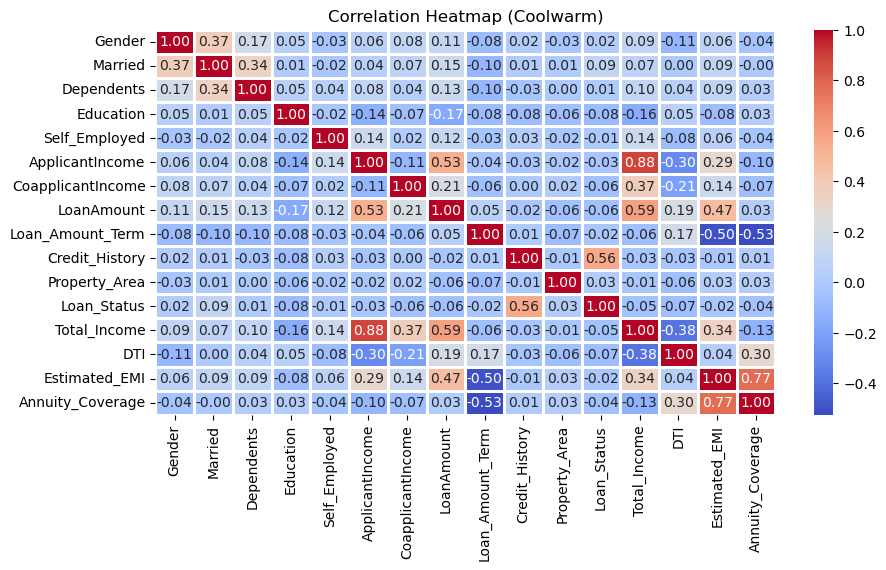

In [12]:
plt.figure(figsize=(10, 5))
# Uses 'coolwarm' for a classic red-blue divergence
sns.heatmap(data.corr(), cmap='coolwarm', fmt='.2f', linewidths=2, annot=True)
plt.title('Correlation Heatmap (Coolwarm)')

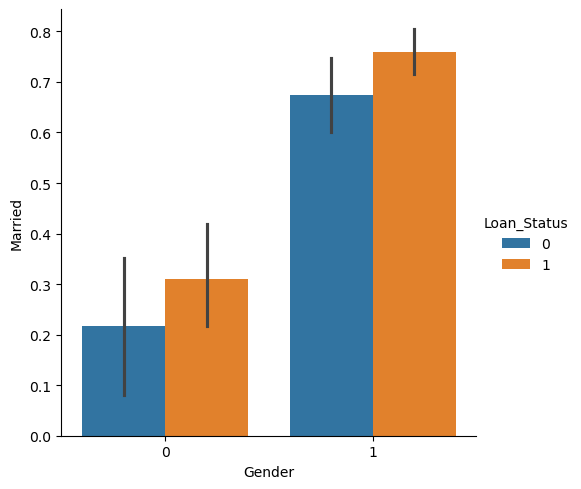

In [13]:
sns.catplot(x="Gender", y="Married",
            hue="Loan_Status", 
            kind="bar", 
            data=data)

In [14]:
from sklearn.model_selection import train_test_split

# Separate target and features
X = data.drop(['Loan_Status'], axis=1)
# Ensure binary numeric target (1 = Approved, 0 = Rejected)
Y = data['Loan_Status'].map({'Y': 1, 'N': 0}) if data['Loan_Status'].dtype == 'O' else data['Loan_Status']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=Y
)

print(f"Training shape: {X_train.shape} | Testing shape: {X_test.shape}")
print(f"Target distribution:\n{Y_train.value_counts(normalize=True)}")

Training shape: (478, 15) | Testing shape: (120, 15)
Target distribution:
Loan_Status
1    0.688285
0    0.311715
Name: proportion, dtype: float64


In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

# Create a preprocessing step that fills NaNs with the median and scales features
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "K-Nearest Neighbors": Pipeline([('prep', preprocessor), ('clf', KNeighborsClassifier(n_neighbors=5))]),
    "Support Vector Classifier": Pipeline([('prep', preprocessor), ('clf', SVC())]),
    "Logistic Regression": Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000))])
}

# Evaluate all models
for name, model in models.items():
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    acc = metrics.accuracy_score(Y_test, Y_pred) * 100
    print(f"Accuracy score of {name} = {acc:.2f}%")

Accuracy score of Random Forest = 80.83%
Accuracy score of K-Nearest Neighbors = 79.17%
Accuracy score of Support Vector Classifier = 80.83%
Accuracy score of Logistic Regression = 81.67%


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Retrieve the fitted Random Forest from your models dictionary
rfc = models["Random Forest"]

# 2. Predict classes and risk probabilities
Y_pred_rfc = rfc.predict(X_test)
Y_probs_rfc = rfc.predict_proba(X_test)[:, 1]

print("=== Random Forest Classification Report ===")
print(classification_report(Y_test, Y_pred_rfc, target_names=['Default / Reject (0)', 'Approved (1)']))

print(f"ROC-AUC Score: {roc_auc_score(Y_test, Y_probs_rfc):.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(Y_test, Y_pred_rfc))

=== Random Forest Classification Report ===
                      precision    recall  f1-score   support

Default / Reject (0)       0.86      0.47      0.61        38
        Approved (1)       0.80      0.96      0.87        82

            accuracy                           0.81       120
           macro avg       0.83      0.72      0.74       120
        weighted avg       0.82      0.81      0.79       120

ROC-AUC Score: 0.7811

=== Confusion Matrix ===
[[18 20]
 [ 3 79]]


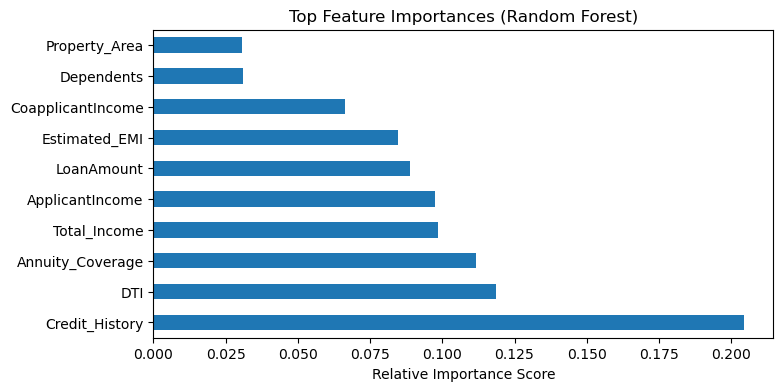

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances
importance = pd.Series(rfc.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh', figsize=(8, 4))

plt.title('Top Feature Importances (Random Forest)')
plt.xlabel('Relative Importance Score')
plt.show()

In [22]:
import joblib

# Save the trained model matching your repository architecture
joblib.dump(rfc, 'credit_underwriting_pipeline.pkl')
print("Model saved successfully as credit_underwriting_pipeline.pkl!")

Model saved successfully as credit_underwriting_pipeline.pkl!
